In [1]:
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/salary/nasdaq100.csv', sep=';')

In [6]:
df.head()

,Date,Starting (USD),Ending (USD)
0,01.01.24,16800,16500
1,01.12.23,15900,16100
2,01.11.23,15800,15300
3,01.10.23,16100,16200
4,01.09.23,16300,15700


In [7]:
df.isnull().sum()

Date              0
Starting (USD)    0
Ending (USD)      0
dtype: int64

In [9]:
#df.drop('Date', axis=1)  # column axis=1 
                         # row axis=0
df = df.drop(columns = ['Date'])

In [10]:
df.head()

,Starting (USD),Ending (USD)
0,16800,16500
1,15900,16100
2,15800,15300
3,16100,16200
4,16300,15700


Text(0.5, 1.0, 'Bitcoin Stock Price')

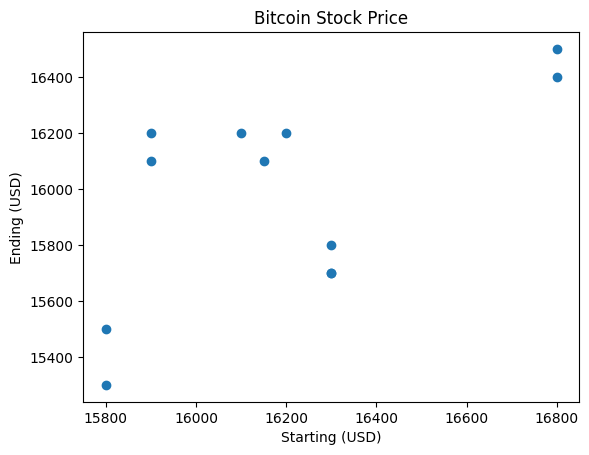

In [13]:
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Bitcoin Stock Price')

In [16]:
x = df.drop('Ending (USD)', axis=1)

In [17]:
x.head()

,Starting (USD)
0,16800
1,15900
2,15800
3,16100
4,16300


In [18]:
y = df[['Ending (USD)']]

In [19]:
y.head()

,Ending (USD)
0,16500
1,16100
2,15300
3,16200
4,15700


**Linear_Regression**

In [20]:
from sklearn.linear_model import LinearRegression

In [21]:
reg = LinearRegression()

In [22]:
x.mean()

Starting (USD)    16195.833333
dtype: float64

In [23]:
y.mean()

Ending (USD)    15975.0
dtype: float64

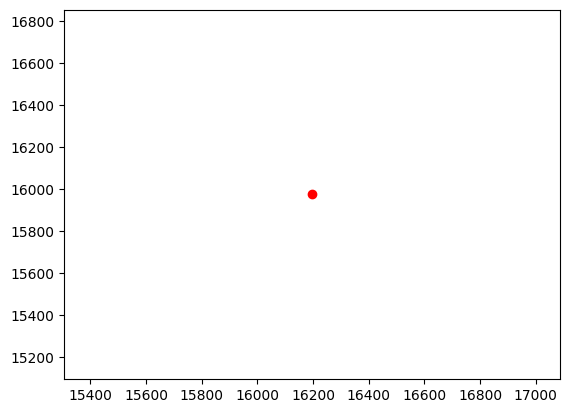

In [29]:
plt.scatter(x.mean(), y.mean(), color='red')

Text(0.5, 1.0, 'Bitcoin Stock Price')

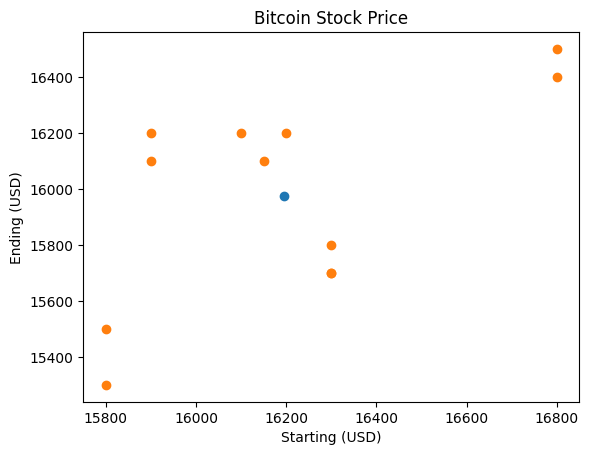

In [30]:
plt.scatter(x.mean(), y.mean())
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Bitcoin Stock Price')

In [33]:
reg.fit(x, y)     #train the model

LinearRegression()

In [38]:
m = reg.coef_
m

array([[0.65258293]])

In [39]:
c = reg.intercept_
c

array([5405.87555702])

In [37]:
# y = mx + c

In [40]:
m * 16700 + c

array([[16304.0105628]])

In [41]:
reg.predict([[16700]])

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[16304.0105628]])

In [43]:
df['Predicted_y'] = reg.predict(x)
df.head()

,Starting (USD),Ending (USD),Predicted_y
0,16800,16500,16369.268856
1,15900,16100,15781.944215
2,15800,15300,15716.685922
3,16100,16200,15912.460802
4,16300,15700,16042.977389


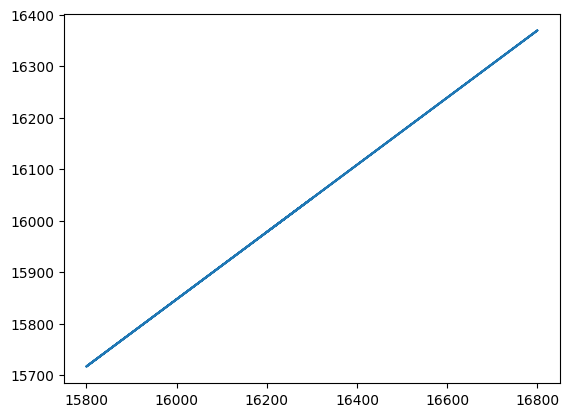

In [44]:
plt.plot(x, reg.predict(x))

Text(0.5, 1.0, 'Bitcoin Stock Price')

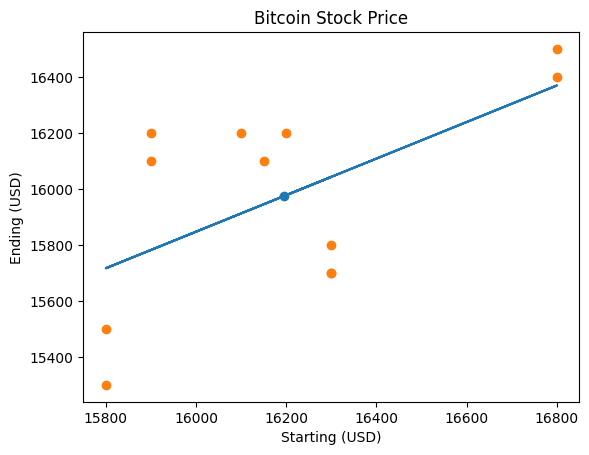

In [45]:
plt.plot(x, reg.predict(x))
plt.scatter(x.mean(), y.mean())
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Bitcoin Stock Price')


**lose_Cost_Function**

In [47]:
df['lose'] = df['Ending (USD)'] - df['Predicted_y']

In [48]:
df.head()

,Starting (USD),Ending (USD),Predicted_y,lose
0,16800,16500,16369.268856,130.731144
1,15900,16100,15781.944215,318.055785
2,15800,15300,15716.685922,-416.685922
3,16100,16200,15912.460802,287.539198
4,16300,15700,16042.977389,-342.977389


In [49]:
#MSE & MAE
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [50]:
mse = mean_squared_error(df['Ending (USD)'], df['Predicted_y'])

In [51]:
mse

80411.23397700385

In [52]:
mae = mean_absolute_error(df['Ending (USD)'], df['Predicted_y'])

In [53]:
mae

260.3840017604666

In [54]:
df['lose']

0     130.731144
1     318.055785
2    -416.685922
3     287.539198
4    -342.977389
5      30.731144
6     418.055785
7    -216.685922
8     154.910051
9    -242.977389
10    222.280904
11   -342.977389
Name: lose, dtype: float64

In [55]:
abs(df['lose'])

0     130.731144
1     318.055785
2     416.685922
3     287.539198
4     342.977389
5      30.731144
6     418.055785
7     216.685922
8     154.910051
9     242.977389
10    222.280904
11    342.977389
Name: lose, dtype: float64

In [56]:
sum(abs(df['lose']))

3124.6080211255994

In [57]:
sum(abs(df['lose'])) / len(x)

260.3840017604666

In [58]:
reg.score(x,y)


0.3577804940272571

Text(0.5, 1.0, 'Bitcoin Stock Price')

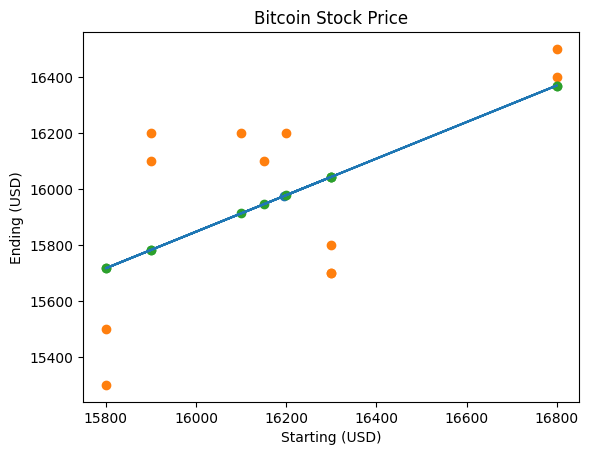

In [59]:
plt.plot(x, reg.predict(x))
plt.scatter(x.mean(), y.mean())
plt.scatter(df['Starting (USD)'], df['Ending (USD)'])
plt.scatter(df['Starting (USD)'], reg.predict(x))
plt.xlabel('Starting (USD)')
plt.ylabel('Ending (USD)')
plt.title('Bitcoin Stock Price')

**R_Square_value/_accuracy_of_LR**

In [62]:
reg.score(x,y)

0.3577804940272571

In [60]:
from sklearn.metrics import r2_score

In [61]:
r2_score(y, reg.predict(x))

0.3577804940272571